# Redes Neuronales Convolucionales - Clasificación de Perros y Gatos

Ejecutable en entorno local (Jupyter Notebook / VSCode)

**Requisitos:** 
- TensorFlow 2.x, Keras, NumPy, Matplotlib, KaggleHub, OpenCV (opcional)
- Credenciales de Kaggle configuradas (archivo kaggle.json en ~/.kaggle/ o variables de entorno KAGGLE_USERNAME y KAGGLE_KEY)

Para ejecutar en un notebook, copie cada celda (# %%) en una celda separada.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
import kagglehub
import cv2  # Opcional, solo para el ejemplo de convolución

# Verificar disponibilidad de GPU
print("--- DIAGNÓSTICO DE HARDWARE TENSORFLOW ---")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"¡Éxito! Se detectaron {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu}")
    # Mostrar información de la GPU (solo en Linux/Colab)
    if sys.platform.startswith('linux'):
        os.system('nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv')
else:
    print("⚠️ No se detectó GPU. TensorFlow usará CPU.")

--- DIAGNÓSTICO DE HARDWARE TENSORFLOW ---
⚠️ No se detectó GPU. TensorFlow usará CPU.


In [3]:
# Descargar datos
try:
    # Descarga automática del dataset (aprox. 3,000 imágenes)
    path_dataset = kagglehub.dataset_download("birajsth/cats-and-dogs-filtered")
    print(f"Dataset descargado en: {path_dataset}")
    
    # Verificar la estructura interna
    if 'cats_and_dogs_filtered' in os.listdir(path_dataset):
        PATH = os.path.join(path_dataset, 'cats_and_dogs_filtered')
    else:
        PATH = path_dataset
    
    train_dir = os.path.join(PATH, 'train')
    validation_dir = os.path.join(PATH, 'validation')
    
    if not os.path.exists(train_dir) or not os.path.exists(validation_dir):
        raise FileNotFoundError("La estructura del dataset no es la esperada.")
        
except Exception as e:
    print("Error al descargar el dataset. Asegúrate de que:")
    print("  - Tienes conexión a Internet.")
    print("  - Tu archivo kaggle.json está en ~/.kaggle/ o las variables de entorno están configuradas.")
    print("  - El dataset 'birajsth/cats-and-dogs-filtered' es público.")
    print(f"Detalles del error: {e}")
    sys.exit(1)

100%|██████████| 131M/131M [00:28<00:00, 4.82MB/s] 

Extracting files...


Dataset descargado en: C:\Users\LUIS PC\.cache\kagglehub\datasets\birajsth\cats-and-dogs-filtered\versions\1


## 4. Preparación de los Datos con image_dataset_from_directory

 Se crean generadores de datos que cargan y preprocesan imágenes sobre la marcha.

In [4]:
BATCH_SIZE = 32
IMG_SIZE = (180, 180)

print("\n--- Cargando set de entrenamiento ---")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\n--- Cargando set de validación ---")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Dividir validación en validación pura y test (50/50)
total_val_batches = validation_dataset.cardinality().numpy()
val_batches = total_val_batches // 2
val_dataset = validation_dataset.take(val_batches)
test_dataset = validation_dataset.skip(val_batches)

print(f"\nEstructura final:")
print(f"  - Lotes de entrenamiento: {train_dataset.cardinality().numpy()}")
print(f"  - Lotes de validación pura: {val_dataset.cardinality().numpy()}")
print(f"  - Lotes de test: {test_dataset.cardinality().numpy()}")

# Nombres de clases
class_names = train_dataset.class_names


--- Cargando set de entrenamiento ---
Found 2000 files belonging to 2 classes.

--- Cargando set de validación ---
Found 1000 files belonging to 2 classes.

Estructura final:
  - Lotes de entrenamiento: 63
  - Lotes de validación pura: 16
  - Lotes de test: 16


In [5]:
print(f"Clases: {class_names} (0: {class_names[0]}, 1: {class_names[1]})")

Clases: ['cats', 'dogs'] (0: cats, 1: dogs)


## 5. Exploración Visual del Dataset (EDA)

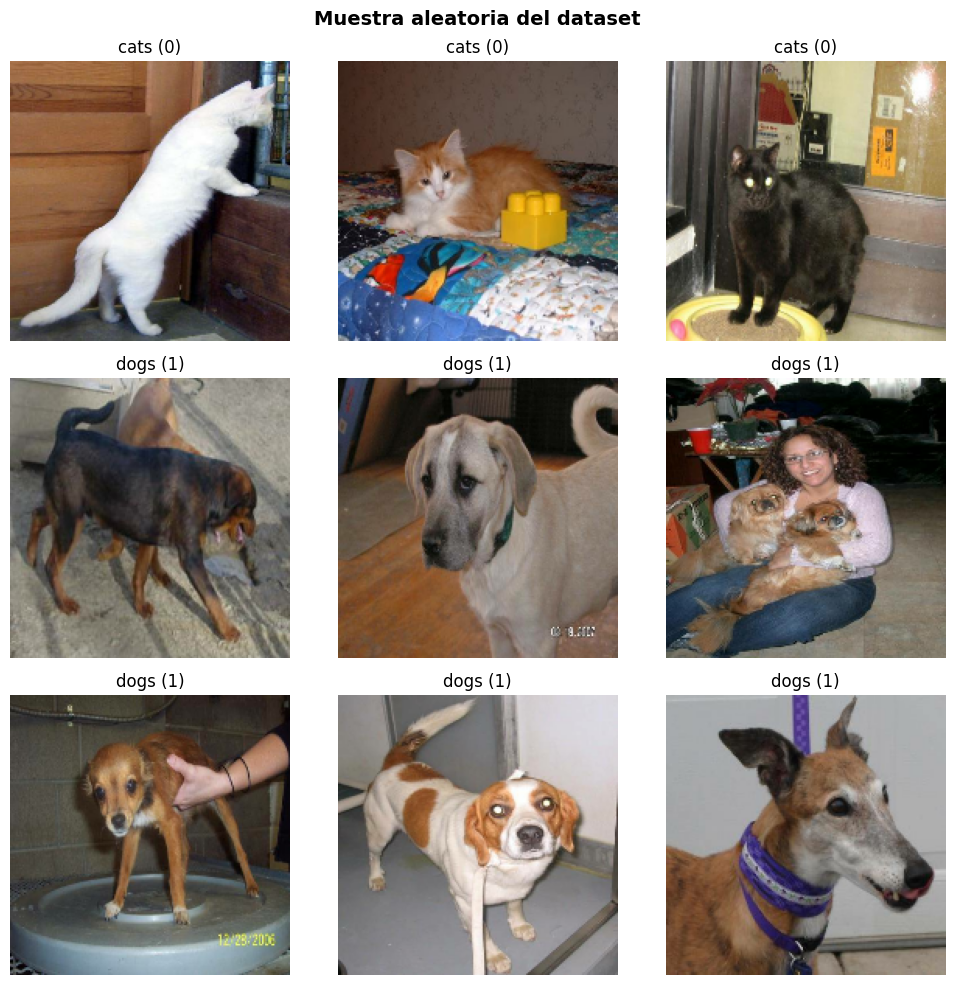

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"{class_names[labels[i]]} ({labels[i].numpy()})")
        plt.axis("off")
plt.suptitle("Muestra aleatoria del dataset", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


## 6. Definición de Callbacks Inteligentes

- EarlyStopping: detiene el entrenamiento si no hay mejora.
- ModelCheckpoint: guarda el mejor modelo.

In [7]:
def get_callbacks(model_name):
    """Retorna una lista de callbacks estándar para el experimento."""
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f'{model_name}_best.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

## 7. Modelo CNN Manual Base (Sin Regularización)

Arquitectura secuencial clásica: Conv -> MaxPool x3, luego Flatten y Dense.

In [8]:
inputs = keras.Input(shape=(180, 180, 3), name="input")
x = layers.Rescaling(1./255)(inputs)  # Normalización a [0,1]
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_manual = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Manual_Base")
model_manual.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_manual.summary()

# Entrenamiento del modelo base (15 épocas, con early stopping)
history_manual = model_manual.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=get_callbacks("manual_base")
)

Model: "CNN_Manual_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,276,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,370,177 (12.86 MB)

 Trainable params: 3,370,177 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.5093 - loss: 0.7196
Epoch 1: val_loss improved from None to 0.76798, saving model to manual_base_best.keras

Epoch 1: finished saving model to manual_base_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 442ms/step - accuracy: 0.5180 - loss: 0.7011 - val_accuracy: 0.0664 - val_loss: 0.7680
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.5892 - loss: 0.6707
Epoch 2: val_loss improved from 0.76798 to 0.54065, saving model to manual_base_best.keras

Epoch 2: finished saving model to manual_base_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 420ms/step - accuracy: 0.6080 - loss: 0.6568 - val_accuracy: 0.8262 - val_loss: 0.5407
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.6733 - loss: 0.6082
Epoch 3: val_loss improved from 0.54065 to 0.46645, saving model to manual_base_best.keras

Epoch 3: finished saving model to manual_base_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 475ms/step - accuracy: 0.7000 -

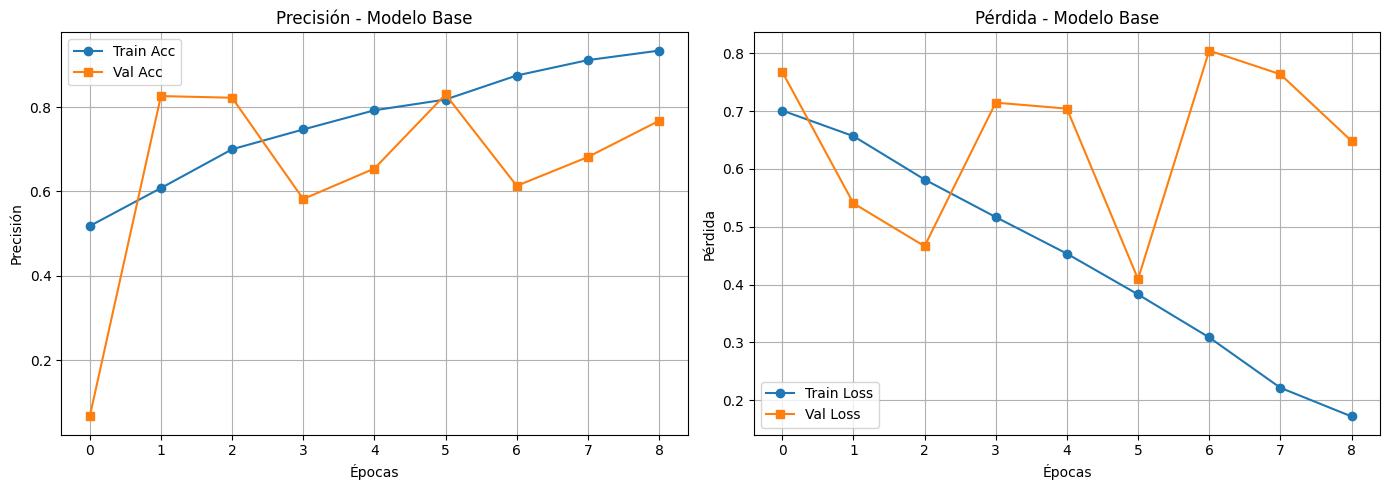

In [9]:
acc = history_manual.history['accuracy']
val_acc = history_manual.history['val_accuracy']
loss = history_manual.history['loss']
val_loss = history_manual.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc', marker='o')
plt.plot(epochs_range, val_acc, label='Val Acc', marker='s')
plt.title('Precisión - Modelo Base')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Val Loss', marker='s')
plt.title('Pérdida - Modelo Base')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Modelo CNN con Regularización (Data Augmentation + Dropout)

In [10]:
# Pipeline de aumento de datos
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

# Construcción del modelo
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)  # Regularización
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_regularized = keras.Model(inputs, outputs, name="CNN_Regularizada")
model_regularized.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_regularized.summary()

# %%
history_reg = model_regularized.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=get_callbacks("manual_regularized")
)

Model: "CNN_Regularizada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,276,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,370,177 (12.86 MB)

 Trainable params: 3,370,177 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.4624 - loss: 0.7550
Epoch 1: val_loss improved from None to 0.68813, saving model to manual_regularized_best.keras

Epoch 1: finished saving model to manual_regularized_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 418ms/step - accuracy: 0.4755 - loss: 0.7107 - val_accuracy: 0.9766 - val_loss: 0.6881
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.4910 - loss: 0.6933
Epoch 2: val_loss did not improve from 0.68813
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 500ms/step - accuracy: 0.4960 - loss: 0.6936 - val_accuracy: 0.0293 - val_loss: 0.7113
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.5353 - loss: 0.6891
Epoch 3: val_loss did not improve from 0.68813
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 492ms/step - accuracy: 0.5355 - loss: 0.6878 - val_accuracy: 0.2266 - val_loss: 0.6975
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.5644 - loss: 0.6870
Epoch 4: val_loss improved from 0.68813 to 0.687

In [14]:
def plot_training_history(history, model_name="Modelo"):
    # Extraer métricas
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    
    # Asegurar que todas tienen la misma longitud
    min_len = min(len(acc), len(val_acc), len(loss), len(val_loss))
    
    # Truncar al mínimo común
    acc = acc[:min_len]
    val_acc = val_acc[:min_len]
    loss = loss[:min_len]
    val_loss = val_loss[:min_len]
    
    epochs_range = range(1, min_len + 1)  # Empieza en 1 para más legibilidad
    
    # Crear figura
    plt.figure(figsize=(14, 5))
    
    # Gráfica 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Entrenamiento (Train)', marker='o', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validación (Val)', marker='s', linewidth=2)
    plt.title(f'Precisión - {model_name}', fontsize=12, weight='bold')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1])
    
    # Gráfica 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Entrenamiento (Train)', marker='o', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validación (Val)', marker='s', linewidth=2)
    plt.title(f'Pérdida - {model_name}', fontsize=12, weight='bold')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.suptitle(f'Diagnóstico de Desempeño: {model_name}', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    # Imprimir resumen
    if min_len > 0:
        print(f"\nResumen - {model_name}:")
        print(f"   Épocas completadas: {min_len}")
        print(f"   Mejor Accuracy Train: {max(acc)*100:.2f}%")
        print(f"   Mejor Accuracy Val: {max(val_acc)*100:.2f}%")
        print(f"   Mejor Loss Val: {min(val_loss):.4f}")

## 11. Evaluación Formal de Ambos Modelos

In [15]:
loss_base, acc_base = model_manual.evaluate(test_dataset, verbose=0)
loss_reg, acc_reg = model_regularized.evaluate(test_dataset, verbose=0)

print("="*50)
print("EVALUACIÓN EN TEST")
print(f"CNN Manual Base  Pérdida: {loss_base:.4f} | Precisión: {acc_base*100:.2f}%")
print(f"CNN Regularizada Pérdida: {loss_reg:.4f} | Precisión: {acc_reg*100:.2f}%")
print("="*50)

EVALUACIÓN EN TEST
CNN Manual Base  Pérdida: 0.8389 | Precisión: 57.17%
CNN Regularizada Pérdida: 0.8384 | Precisión: 29.92%


## 12. Inferencia con una Imagen Aleatoria (ejemplo)

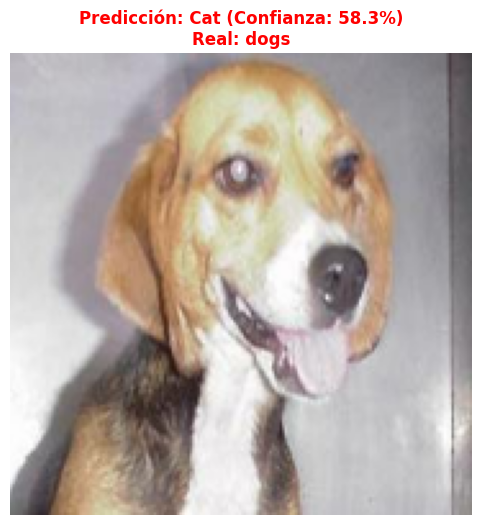

In [31]:
for images, labels in test_dataset.take(1):
    idx = np.random.randint(0, images.shape[0])
    img_sample = images[idx]
    true_label = labels[idx].numpy()
    break

# Preparar para predicción (batch de tamaño 1)
img_batch = tf.expand_dims(img_sample, axis=0)

# Predecir con el modelo regularizado (o el que prefieras)
pred = model_regularized.predict(img_batch, verbose=0)[0][0]
pred_class = "Dog" if pred > 0.5 else "Cat"
confidence = pred * 100 if pred > 0.5 else (1 - pred) * 100
true_class = class_names[true_label]

# Mostrar resultado
plt.figure(figsize=(6, 6))
plt.imshow(img_sample.numpy().astype("uint8"))
color = 'green' if pred_class.lower() == true_class.lower() else 'red'
plt.title(f"Predicción: {pred_class} (Confianza: {confidence:.1f}%)\nReal: {true_class}",
          color=color, fontsize=12, weight='bold')
plt.axis('off')
plt.show()

## 13. Transfer Learning con ResNet50V2 (Feature Extraction)

In [32]:
base_model = keras.applications.ResNet50V2(
    weights='imagenet',
    input_shape=(180, 180, 3),
    include_top=False
)
base_model.trainable = False  # Congelar pesos

# Preprocesamiento específico de ResNet
preprocess_input = keras.applications.resnet_v2.preprocess_input

# Construcción del nuevo modelo
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)  # Modo inferencia
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_transfer = keras.Model(inputs, outputs, name="Transfer_ResNet50V2")
model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_transfer.summary()

# %%
# Entrenamiento (pocas épocas porque la base ya es muy buena)
history_transfer = model_transfer.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=get_callbacks("transfer_resnet")
)

# %%
# Evaluación del modelo de transfer learning
loss_tf, acc_tf = model_transfer.evaluate(test_dataset, verbose=0)
print("="*50)
print("EVALUACIÓN EN TEST (Transfer Learning)")
print(f"ResNet50V2 + Fine-Tuning -> Pérdida: {loss_tf:.4f} | Precisión: {acc_tf*100:.2f}%")
print("="*50)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


Model: "Transfer_ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 6, 6, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.7924 - loss: 0.4453
Epoch 1: val_loss improved from None to 0.06035, saving model to transfer_resnet_best.keras

Epoch 1: finished saving model to transfer_resnet_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 943ms/step - accuracy: 0.8760 - loss: 0.2877 - val_accuracy: 0.9805 - val_loss: 0.0603
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.9508 - loss: 0.1258
Epoch 2: val_loss did not improve from 0.06035
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9455 - loss: 0.1414 - val_accuracy: 0.9785 - val_loss: 0.0638
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.9579 - loss: 0.1097
Epoch 3: val_loss improved from 0.06035 to 0.03900, saving model to transfer_resnet_best.keras

Epoch 3: finished saving model to transfer_resnet_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9530 - loss: 0.1205 - val_accuracy: 0.9863 - val_loss: 0.0390
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━

## 14. Comparativa Final de Precisión en Test

C:\Users\LUIS PC\AppData\Local\Temp\ipykernel_20620\1792211423.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modelos, fontsize=11, fontweight='medium')


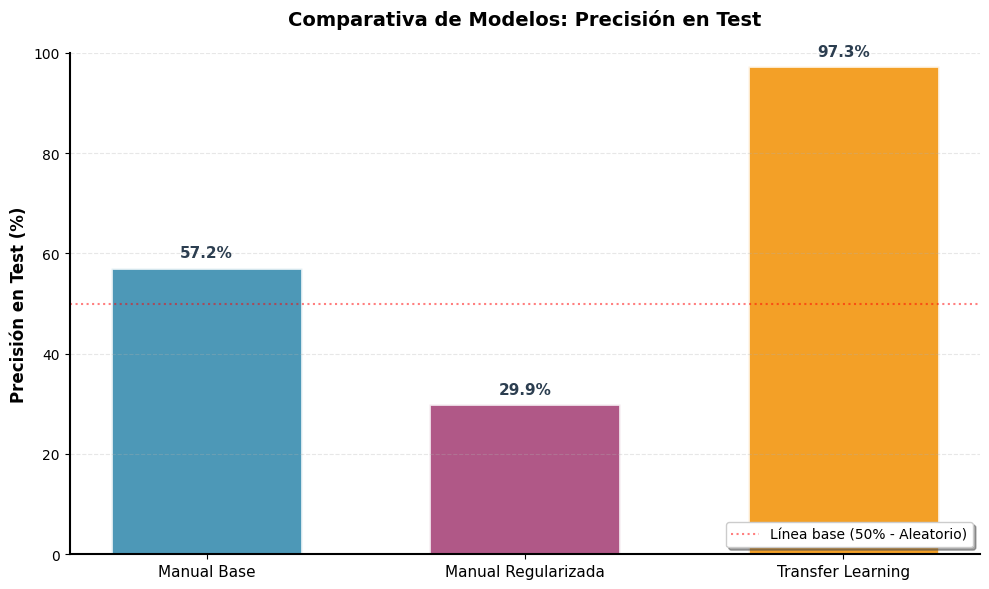

In [36]:
# ============================================
# COMPARATIVA DE PRECISIÓN EN TEST (VERSIÓN MEJORADA)
# ============================================

# Configuración de datos
modelos = ['Manual Base', 'Manual Regularizada', 'Transfer Learning']
precisiones = [acc_base, acc_reg, acc_tf]

# Colores más profesionales y modernos
colores = ['#2E86AB', '#A23B72', '#F18F01']  # Azul, Morado, Naranja

# Crear figura con mejor tamaño
fig, ax = plt.subplots(figsize=(10, 6))

# Barras con mejor estilo
bars = ax.bar(
    modelos, 
    [p*100 for p in precisiones], 
    color=colores,
    edgecolor='white',
    linewidth=2,
    alpha=0.85,
    width=0.6
)

# Personalización de ejes y títulos
ax.set_ylabel('Precisión en Test (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparativa de Modelos: Precisión en Test', 
             fontsize=14, fontweight='bold', pad=20)

# Límites y grid
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.8)

# Eliminar bordes superiores y derechos (estilo moderno)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Añadir valor sobre cada barra con mejor formato
for bar, prec in zip(bars, precisiones):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + 1.5,
        f'{prec*100:.1f}%',
        ha='center', 
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#2c3e50'
    )

# Añadir línea de referencia (baseline)
ax.axhline(y=50, color='red', linestyle=':', alpha=0.5, linewidth=1.5, 
           label='Línea base (50% - Aleatorio)')

# Leyenda
ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)

# Ajustar etiquetas del eje X
ax.set_xticklabels(modelos, fontsize=11, fontweight='medium')

# Añadir anotación con el mejor modelo
best_idx = np.argmax(precisiones)
best_model = modelos[best_idx]
best_acc = precisiones[best_idx] * 100


# Ajustar layout
plt.tight_layout()
plt.show()

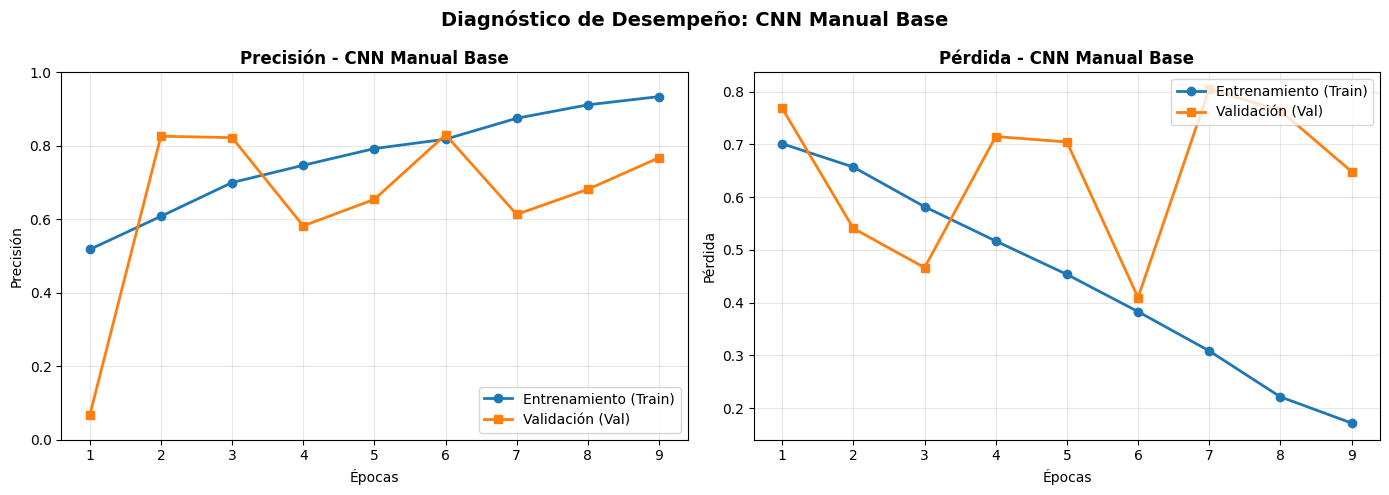


Resumen - CNN Manual Base:
   Épocas completadas: 9
   Mejor Accuracy Train: 93.40%
   Mejor Accuracy Val: 83.01%
   Mejor Loss Val: 0.4096


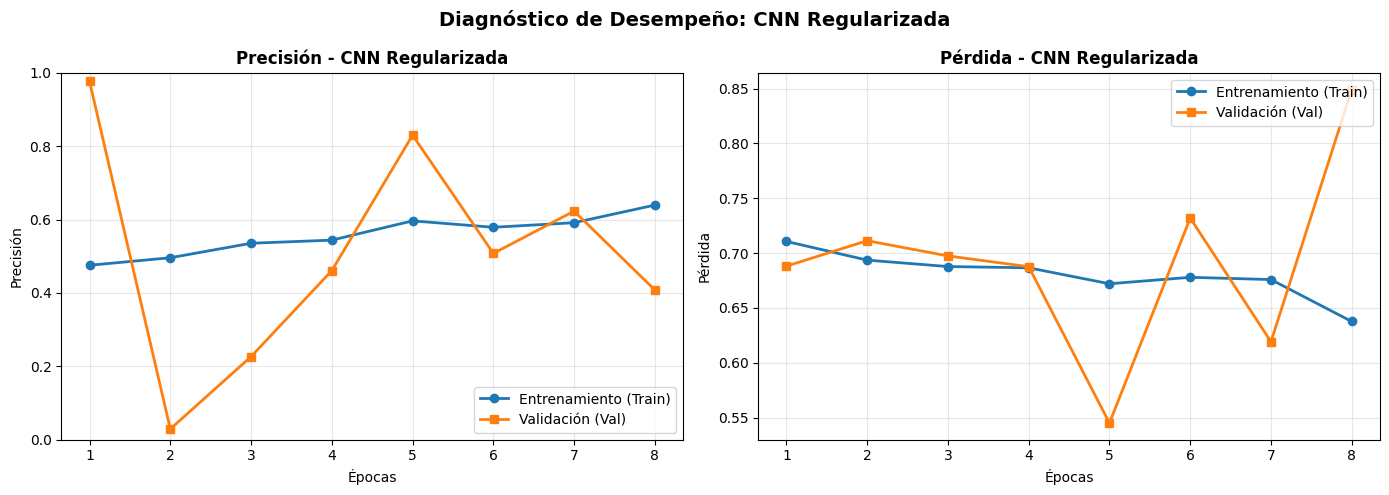


Resumen - CNN Regularizada:
   Épocas completadas: 8
   Mejor Accuracy Train: 63.95%
   Mejor Accuracy Val: 97.66%
   Mejor Loss Val: 0.5451


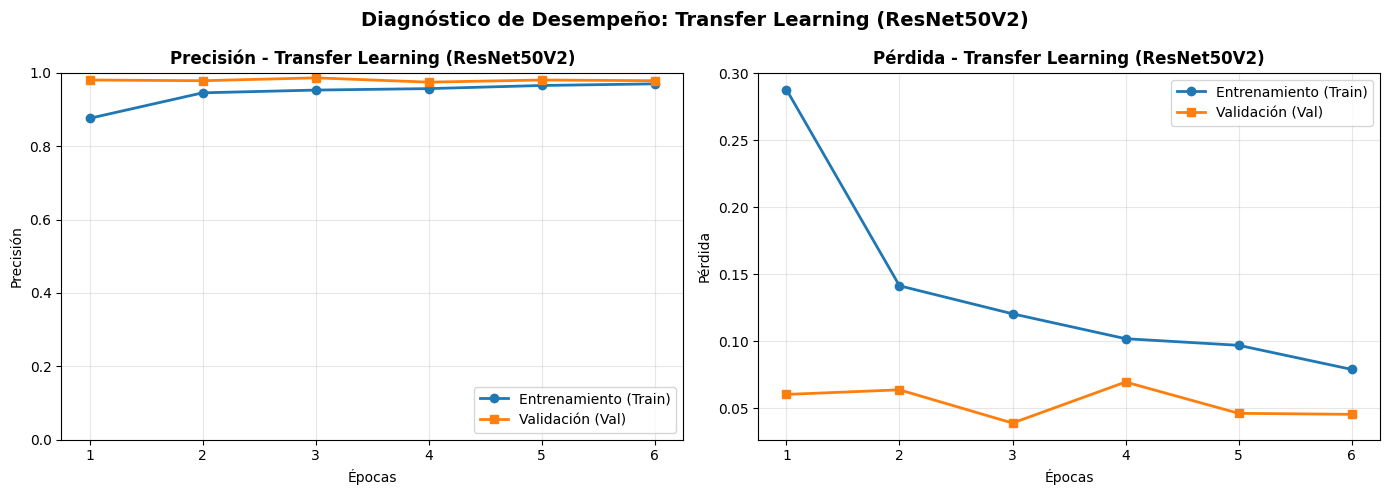


Resumen - Transfer Learning (ResNet50V2):
   Épocas completadas: 6
   Mejor Accuracy Train: 97.00%
   Mejor Accuracy Val: 98.63%
   Mejor Loss Val: 0.0390


In [34]:
# Para el modelo manual base
plot_training_history(history_manual, "CNN Manual Base")

# Para el modelo regularizado
plot_training_history(history_reg, "CNN Regularizada")

# Para el modelo de transfer learning
plot_training_history(history_transfer, "Transfer Learning (ResNet50V2)")